In [11]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [12]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation: str
    operation2: str
    finalNumber: int
    finalNumber2: int

In [13]:
def add_node(state: AgentState) -> AgentState:
    """This node adds numbers 1 and 2"""
    
    state['finalNumber'] = state['number1'] + state['number2']
    return state

def substract_node(state: AgentState) -> AgentState:
    """This node substract numbers 1 and 2"""

    state['finalNumber'] = state['number1'] - state['number2']
    return state

def router(state: AgentState) -> AgentState:
    
    if state["operation"] == "+":
        return "addition_operaion"
    elif state["operation"] == "-":
        return "substraction_operation"

In [14]:
def add_node2(state: AgentState) -> AgentState:
    """This node adds numbers 3 and 4"""
    
    state['finalNumber2'] = state['number3'] + state['number4']
    return state

def substract_node2(state: AgentState) -> AgentState:
    """This node substract numbers 3 and 4"""

    state['finalNumber2'] = state['number3'] - state['number4']
    return state

def router2(state: AgentState) -> AgentState:
    
    if state["operation2"] == "+":
        return "addition_operaion2"
    elif state["operation2"] == "-":
        return "substraction_operation2"

In [15]:
graph = StateGraph(AgentState)
graph.add_node("router", lambda state:state)
graph.add_node("router2", lambda state:state)
graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    router,
    {
        "addition_operaion":"add_node",
        "substraction_operation":"substract_node"
    }
)
graph.add_node("add_node", add_node)
graph.add_node("substract_node", substract_node)
graph.add_edge("add_node", "router2")
graph.add_edge("substract_node", "router2")
graph.add_conditional_edges(
    "router2",
    router2,
    {
        "addition_operaion2":"add_node2",
        "substraction_operation2":"substract_node2"
    }
)
graph.add_node("add_node2", add_node2)
graph.add_node("substract_node2", substract_node2)
graph.add_edge("add_node2", END)
graph.add_edge("substract_node2", END)

app = graph.compile()

In [18]:
initial_state = AgentState(number1 = 10, operation="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber= 0, finalNumber2 = 0)
print(app.invoke(initial_state))

{'number1': 10, 'number2': 5, 'number3': 7, 'number4': 2, 'operation': '-', 'operation2': '+', 'finalNumber': 5, 'finalNumber2': 9}


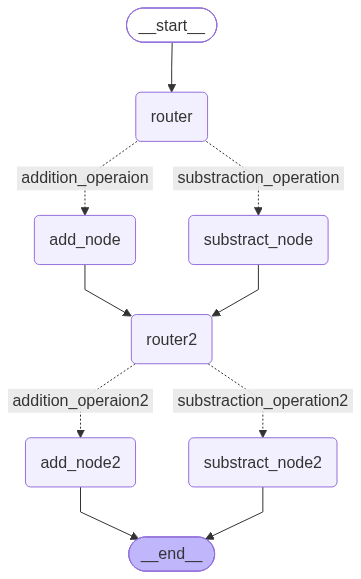

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))